In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
path_mc = "chunks_MC"
path_data = "chunks/"

Data_chunk_num = 10
MC_chunk_num = 2

# Choose MC2 and Data 01
MC_chunk = f"{path_mc}/mc_chunk_{MC_chunk_num:02d}.npz"
data_chunk = f"{path_data}/data_chunk_{Data_chunk_num:02d}.npz"


mc_events = np.load(MC_chunk, allow_pickle=True)
data_events = np.load(data_chunk, allow_pickle=True)

VARIABLES = { "pT_j1": (0, 7000, 50, r"$p_{T}^{j1}$ [GeV]", True), "pT_j2": (0, 7000, 50, r"$p_{T}^{j2}$ [GeV]", True), "eta_j1": (-3, 3, 15, r"$\eta^{j1}$", False), "eta_j2": (-3, 3, 15, r"$\eta^{j2}$", False), "m_jj": (0, 12000, 20, r"$m_{jj}$ [GeV]", True), "tau21_j1": (0, 1.5, 15, r"$\tau_{21}^{j1}$", False), "tau21_j2": (0, 1.5, 15, r"$\tau_{21}^{j2}$", False), "tau32_j1": (0, 1.5, 15, r"$\tau_{32}^{j1}$", False), "tau32_j2": (0, 1.5, 15, r"$\tau_{32}^{j2}$", False), "met": (0, 1800, 50, r"$E_{T}^{miss}$ [GeV]", True), "ht": (0, 1200, 50, r"$H_{T}$ [GeV]", True), "min_dPhi": (0, 3.0, 15, r"$\min \Delta \phi(jet, MET)$", False), }


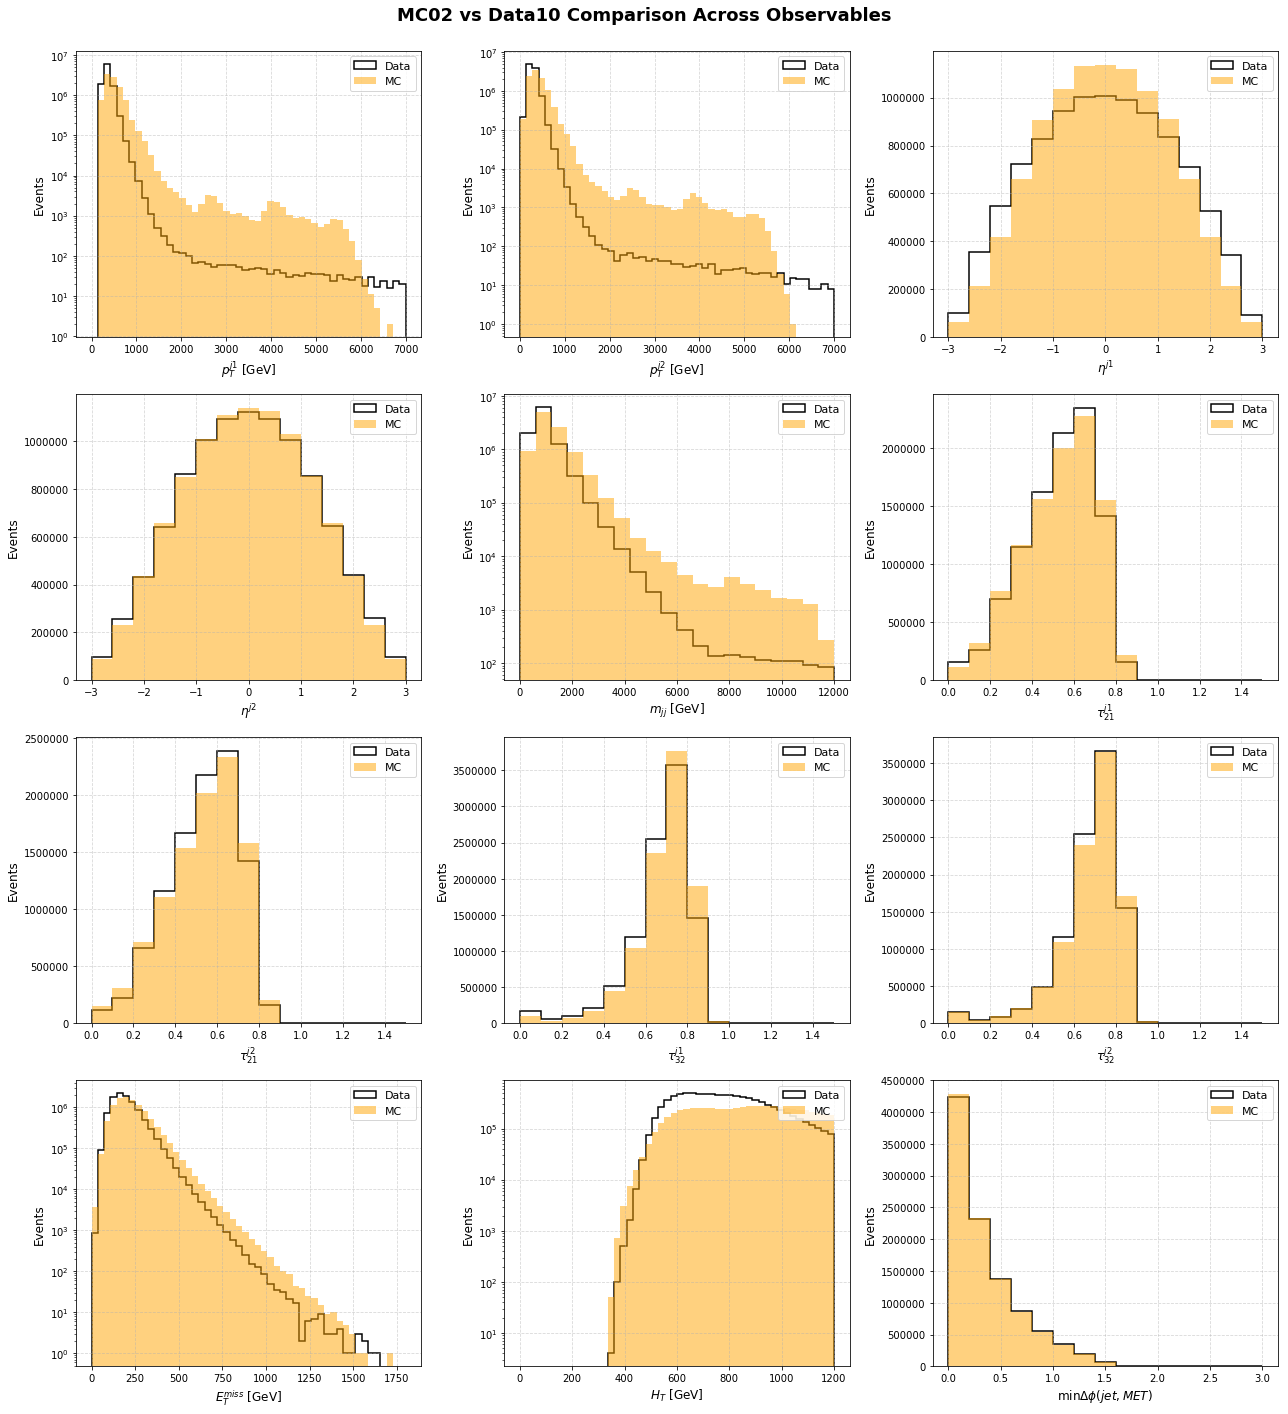

In [12]:
# Plot configuration
n_cols = 3
n_rows = int(np.ceil(len(VARIABLES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Style settings for a cleaner look
# plt.style.use("seaborn-v0_8-muted")
plt.rcParams.update({
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

for i, (var, (xmin, xmax, nbins, xlabel, logy)) in enumerate(VARIABLES.items()):
    ax = axes[i]
    
    if var not in mc_events or var not in data_events:
        print(f"⚠️ Skipping {var}: not found in npz files.")
        continue

    mc_vals = mc_events[var]
    data_vals = data_events[var]
    
    # Drop NaN or inf values
    mc_vals = mc_vals[np.isfinite(mc_vals)]
    data_vals = data_vals[np.isfinite(data_vals)]

    # Plot histograms
    ax.hist(data_vals, bins=nbins, range=(xmin, xmax), 
            histtype="step", color="black", label="Data", linewidth=1.5)
    ax.hist(mc_vals, bins=nbins, range=(xmin, xmax),
            histtype="stepfilled", alpha=0.5, label="MC", color="orange")

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Events")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)
    if logy:
        ax.set_yscale("log")

# Remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Add a main title
fig.suptitle(f"MC{MC_chunk_num:02d} vs Data{Data_chunk_num:02d} Comparison Across Observables", fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for suptitle
plt.show()

# Enhancements included: